# Solve Helmholtz equations: 
\begin{equation}
\begin{cases} 
    u_{xx} + u_{yy} + k^{2}u - q(x,y) = 0 \quad (x,y) \in (-1,1) \times (-1,1) \\ 
    u(-1, y) = u(1,y) = u(x,-1) = u(x,1) = 0, 
\end{cases}
\end{equation} where 
$$
\begin{cases} 
q(x,y) = -(a_{1}\pi)^{2}\sin(a_{1}\pi x)\sin(a_{2} \pi y) - (a_{2} \pi)^{2} \sin(a_{1} \pi x)\sin(a_{2} \pi y) + k^{2} \sin(a_{1} \pi x) \sin(a_{2} \pi y) \\ 
u(x,y) = \sin(a_{1} \pi x) \sin(a_{2} \pi y) 
\end{cases} 
$$

In [16]:
import torch 
from torch import nn
import math 
import numpy as np 
import matplotlib.pyplot as plt 
import torch.nn.init as init
from Helmholtz_utils import * 
from mpl_toolkits.axes_grid1 import make_axes_locatable # allows you to easily add new axes next to an existing plot 
import warnings

# warnings.filterwarnings('ignore') 

import time 

# np.random.seed(1234) 

In [17]:
# MPS or CUDA or CPU 
if torch.backends.mps.is_available(): 
    device = torch.device('mps') 
elif torch.cuda.is_available(): 
    device = torch.device('cuda') 
else: 
    devcie = torch.device('cpu') 

print(f"Wroking on {device}") 

Wroking on mps


# Using Random Feature Model: 
\begin{equation}
u(x,y) = \sum_{i=1}^{Dx} \sum_{k=1}^{Dy}  c_{ik} \cos(<\omega_{i}^{x}, x> + b_{i}^{x}) \cos(<\omega_{k}^{y}, y> + b_{k}^{y}) 
<!-- \end{equation} 
 -->
Only train the coefficients $c_{ik}$

In [18]:
class RFN_coefficients(nn.Module): 
    def __init__(self, Dx, Dy, scale_x = 1.0, scale_y = 1.0):
        super().__init__() 
        # set up parameters for random features 
        self.register_buffer("W_x", torch.randn(1, Dx) * scale_x) 
        self.register_buffer("b_x", 2 * math.pi * torch.rand(Dx)) 
        self.register_buffer("W_y", torch.randn(1, Dy) * scale_y) 
        self.register_buffer("b_y", 2 * math.pi * torch.rand(Dy))
    
    def forward(self, X):
        proj_x = torch.mm(X[:, 0:1], self.W_x) # (N, Dx) 
        proj_y = torch.mm(X[:, 1:2], self.W_y) # (N, Dy) 
        M_x = (proj_x + self.b_x) # (N, Dx)
        M_y = (proj_y + self.b_y) # (N, Dy)
        Phi_x = torch.cos(M_x) 
        Phi_y = torch.cos(M_y) 
        
        return Phi_x, Phi_y # The coefficient matrices inside the cosine function 

In [19]:
class Random_Feature_Model(nn.Module): 
    def __init__(self, Dx, Dy, scale_x = 1.0, scale_y = 1.0, out_dim = 1): 
        super().__init__() 
        self.rff = RFN_coefficients(Dx, Dy, scale_x, scale_y) 
        self.linear = nn.Linear(Dx * Dy, out_dim, bias = False)

        # Optionally initialize linear weights small 
        # nn.init.normal_(self.linear.weight, mean = 0.0, std = 1e-3) 
        # nn.init.zeros_(self.linear.weight) 
        # nn.init.zeros_(self.linear.bias) 

    def forward(self, X): 
        # x must be a float tensor on the smae device as model 
        phi_x, phi_y = self.rff(X) # (N, Dx), (N, Dy)  
        result_einsum = torch.einsum(
            'bi,bj->bij',
            phi_x,
            phi_y
            ).reshape(phi_x.shape[0], -1)
        
        return self.linear(result_einsum) 


In [20]:
class RFN_Helmholtz(nn.Module): 
    def __init__(self, X_train, X_bc, lb, ub, Dx, Dy, scale_x = 1.0, scale_y = 1.0, k = 1, a1 = 1, a2 = 4, out_dim = 1):
        super().__init__() 
        # set up parameters for random features 
        self.Dx = Dx 
        self.Dy = Dy 
        self.scale_x = scale_x
        self.scale_y = scale_y 
        
        # Model setting 
        self.rfn = Random_Feature_Model(Dx, Dy, scale_x, scale_y).to(device) 
        self.k = k 
        self.a1 = a1 
        self.a2 = a2 
        
        # Domain bounds 
        self.lb = torch.as_tensor(lb).float().to(device) 
        self.ub = torch.as_tensor(ub).float().to(device) 

        # Collocation data points 
        self.x = torch.tensor(X_train[:, 0:1], requires_grad = True).float().to(device) 
        self.y = torch.tensor(X_train[:, 1:2], requires_grad = True).float().to(device) 
        self.X_train = torch.tensor(X_train, requires_grad = True).float().to(device) 
        self.N_int = self.x.shape[0]
        
        # Boundary data 
        self.BC_left = torch.tensor(X_bc[:,0:2]).float().to(device) 
        self.BC_right = torch.tensor(X_bc[:,2:4]).float().to(device) 
        self.BC_down = torch.tensor(X_bc[:, 4:6]).float().to(device) 
        self.BC_up = torch.tensor(X_bc[:, 6:8]).float().to(device) 
        self.N_bc = self.BC_left.shape[0]

        # Regularization parameters 
        self.lambda1 = 1.0        
        self.lambda2 = 1.0 
        self.lambda3 = 1.0

        # Iteration parameter 
        self.iter = 0 
        
        # Adam Optimizer 
        self.optimizer_Adam = torch.optim.Adam(self.rfn.parameters(), lr = 2e-4, betas = (0.9, 0.999), weight_decay = 1.0) 
        
        """ 
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer_AdamW,
            factor = 0.5,
            patience = 50
        )
        """
        
        # Optimizers 2nd order optimizer 
        self.optimizer = torch.optim.LBFGS(
            self.rfn.parameters(), # target to be optimized; parameters must be in a list
            lr = 1.0, # learning rate: step length 
            max_iter = 1, # maximum number of iterations 
            max_eval = 50000, # total number of times the closure (loss + backward pass) can be called 
            history_size = 50, 
            tolerance_grad = 1e-7, 
            tolerance_change = 1e-9, 
            line_search_fn = "strong_wolfe"
        ) 

    def q(self, X): 
        a1 = torch.pi * self.a1 
        a2 = torch.pi * self.a2 
        return (self.k ** 2 - (a1) ** 2 - (a2) ** 2)  * torch.sin(a1 * X[:, 0:1]) * torch.sin(a2 * X[:, 1:2])   

        
    def net_u(self, X): # predicted value 
        u = self.rfn(X)
        return u 
   
    def PDE_residual(self, X): 
        u = self.net_u(X) 
        q = self.q(X) 
        
        grad_u = torch.autograd.grad(
            outputs = u, 
            inputs = X, 
            grad_outputs = torch.ones_like(u),
            create_graph = True
        )[0] # shape (N, 2) 

        u_x = grad_u[:, 0:1] 
        u_y = grad_u[:, 1:2]  
        
        u_xx = torch.autograd.grad(
            u_x, X, 
            grad_outputs = torch.ones_like(u_x), 
            create_graph = True
        )[0][:, 0:1]

        u_yy = torch.autograd.grad(
            u_y, X, 
            grad_outputs = torch.ones_like(u_y),
            create_graph = True 
        )[0][:, 1:2]
            
        # PDE residual loss 
        f = u_xx + u_yy + (self.k ** 2) * u - q    
        return f 

    def Bc_loss_func(self):
        u_left = self.net_u(self.BC_left) 
        u_right = self.net_u(self.BC_right) 
        u_down = self.net_u(self.BC_down) 
        u_up = self.net_u(self.BC_up) 
        bc_loss = (torch.mean(torch.pow(u_left,2)) + torch.mean(torch.pow(u_right,2)) + torch.mean(torch.pow(u_down, 2)) + torch.mean(torch.pow(u_up, 2))) * self.lambda2 
        return bc_loss 
        
    # Optimization step
    def loss_func(self): 
        f_pred = self.PDE_residual(self.X_train)
        loss = torch.mean(torch.pow(f_pred, 2)) * self.lambda1 + self.Bc_loss_func() 

        return loss 

    def closure(self): 
        loss_value = self.loss_func() 
        self.optimizer.zero_grad()     # reset gradients
        loss_value.backward()          # compute gradients but only the network weights will be updated 
        return loss_value  

        
    def Optimize(self, nIter_1, nIter_2 = 5000): 
        # self.rfn.train() 
        # Two Phase Optimization
        # Step 1: Adam: gradient descent method 
        for epoch in range(nIter_1):
            # total loss 
            loss = self.loss_func() 
            
            # Backward and optimize 
            # Network parameter update 
            self.optimizer_Adam.zero_grad()
            
            # self.optimizer_Muon.zero_grad()
            loss.backward()
            self.optimizer_Adam.step() # only sees the gradient of the network weights 
           
            if epoch % 100 == 0: 
                print(
                    'It: %d, Loss: %.3e' % 
                    ( 
                        epoch, 
                        loss.item()  
                    )
                )
        # Second Phase Optimization         
        for i in range(nIter_2):
            loss_value = self.optimizer.step(self.closure) # Never pass tensors into optimizer.step
            self.iter += 1
            if self.iter % 100 == 0:
                print('It: %d, Loss: %e' % (self.iter, loss_value.item()))
            

                
    def predict(self, X, X_bc = None): 
        X_test = torch.tensor(X, requires_grad = True).float().to(device) 
        # self.rfn.eval() 
        with torch.no_grad():
            u = self.net_u(X_test)
        f = self.PDE_residual(X_test) 
        u = u.detach().cpu().numpy() 
        f = f.detach().cpu().numpy() 
        return u, f         

# Configurations 

In [30]:
# Domain bounds 
lb = np.array([-1.0, -1.0]) 
ub = np.array([1.0, 1.0]) 
k = 1 
a1 = 1 
a2 = 4                                                 

# Grid point setup 
N_bc = 100
N_x = 40 
N_y = 120 


# Training points 
# Interior part 
X_train_int = interior_points(N_x, N_y, lb[0], ub[0], lb[1], ub[1]) 
print(f"X_train_int shape: {np.shape(X_train_int)}")

X_train_bc = bc_points(N_bc, lb[0], ub[0], lb[1], ub[1])
print(f"X_train_bc shape: {np.shape(X_train_bc)}") 

X_train_int shape: (4800, 2)
X_train_bc shape: (100, 8)


# Generate Test data and solution  

In [31]:
# Generate test data 
N = 100 
X_test, u_test = test_data(N)


print(f"X_test shape: {X_test.shape}") 
print(f"u_test shape: {u_test.shape}") 

X_test shape: (10000, 2)
u_test shape: (10000, 1)


# Training on Non-noisy Data 

In [32]:
noise = 0.0 
Dx = 40 # 40  
Dy = 160 # 160  
scale_x = 2.0 # 2.0
scale_y = 8.0 # 10.0 

training_sets = np.load(
    "Helmholtz_2d_training_points_4800_sets.npy",
    allow_pickle=True
)
data = training_sets[1] 
X_train_int = data["X_train_int"] 
X_train_bc = data["X_train_bc"] 
# training 
start = time.time() 

model =  RFN_Helmholtz(X_train_int, X_train_bc, lb, ub, Dx, Dy, scale_x, scale_y, k, a1, a2) 
model.Optimize(2500, 3000) 
end = time.time() 

It: 0, Loss: 9.478e+03
It: 100, Loss: 2.305e+02
It: 200, Loss: 3.809e+01
It: 300, Loss: 1.568e+01
It: 400, Loss: 1.051e+01
It: 500, Loss: 8.015e+00
It: 600, Loss: 6.468e+00
It: 700, Loss: 5.440e+00
It: 800, Loss: 4.709e+00
It: 900, Loss: 4.144e+00
It: 1000, Loss: 3.677e+00
It: 1100, Loss: 3.270e+00
It: 1200, Loss: 2.909e+00
It: 1300, Loss: 2.584e+00
It: 1400, Loss: 2.291e+00
It: 1500, Loss: 2.028e+00
It: 1600, Loss: 1.792e+00
It: 1700, Loss: 1.580e+00
It: 1800, Loss: 1.390e+00
It: 1900, Loss: 1.221e+00
It: 2000, Loss: 1.071e+00
It: 2100, Loss: 9.376e-01
It: 2200, Loss: 8.196e-01
It: 2300, Loss: 7.154e-01
It: 2400, Loss: 6.235e-01
It: 100, Loss: 1.805880e-01
It: 200, Loss: 1.008592e-01
It: 300, Loss: 4.859217e-02
It: 400, Loss: 3.300559e-02
It: 500, Loss: 2.518759e-02
It: 600, Loss: 1.967969e-02
It: 700, Loss: 1.669143e-02
It: 800, Loss: 1.514917e-02
It: 900, Loss: 1.378754e-02
It: 1000, Loss: 1.305295e-02
It: 1100, Loss: 1.226859e-02
It: 1200, Loss: 1.157195e-02
It: 1300, Loss: 1.08927

# Test the accuracy of the learned solution 

In [33]:
# evaluations 
u_pred, f_pred = model.predict(X_test)  

print(f"u_pred shape: {np.shape(u_pred)}") 
# print(f"f_pred shape: {np.shape(f_pred)}")  
print(f"u_test shape: {np.shape(u_test)}") 

error_u = np.linalg.norm(abs(u_test - u_pred), 2) / np.linalg.norm(u_test, 2) # relative L^{2} square norm 
# error_f = np.linalg.norm(abs(f_pred), ord = np.inf) 


print('Error u: %e' % (error_u)) 
# print('PDE loss: %e' % (error_f)) 
print(f'Training time is {end - start:.2f} seconds')



u_pred shape: (10000, 1)
u_test shape: (10000, 1)
Error u: 4.067385e-03
Training time is 905.84 seconds


# Collecting Error Data 

In [20]:
noise = 0.0 
err_l2 = np.zeros([10]) 
err_linf = np.zeros([10]) 
Training_time = np.zeros([10]) 
k = 1 
a1 = 1
a2 = 4 
Dx = 40 
Dy = 160 
scale_x = 2.0 
scale_y = 8.0 
training_sets = np.load(
    "Helmholtz_2d_training_points_4800_sets.npy",
    allow_pickle=True
)
for k in range(10): 
    data = training_sets[k] 
    X_train_int = data["X_train_int"] 
    X_train_bc = data["X_train_bc"] 
    model = RFN_Helmholtz(X_train_int, X_train_bc, lb, ub, Dx, Dy, scale_x, scale_y, k, a1, a2) 
    start = time.time() 
    model.Optimize(2500, 3000) 
    end = time.time() 
    u_pred, f_pred = model.predict(X_test) 
    err_l2[k] = np.linalg.norm(abs(u_test - u_pred), 2) / np.linalg.norm(u_test, 2)
    err_linf[k] = np.max(np.abs(u_test - u_pred))
    Training_time[k] = (end - start) 

It: 0, Loss: 8.272e+03
It: 100, Loss: 1.205e+02
It: 200, Loss: 4.220e+01
It: 300, Loss: 2.872e+01
It: 400, Loss: 2.295e+01
It: 500, Loss: 1.928e+01
It: 600, Loss: 1.662e+01
It: 700, Loss: 1.465e+01
It: 800, Loss: 1.319e+01
It: 900, Loss: 1.209e+01
It: 1000, Loss: 1.123e+01
It: 1100, Loss: 1.053e+01
It: 1200, Loss: 9.931e+00
It: 1300, Loss: 9.396e+00
It: 1400, Loss: 8.901e+00
It: 1500, Loss: 8.432e+00
It: 1600, Loss: 7.980e+00
It: 1700, Loss: 7.542e+00
It: 1800, Loss: 7.115e+00
It: 1900, Loss: 6.705e+00
It: 2000, Loss: 6.292e+00
It: 2100, Loss: 5.896e+00
It: 2200, Loss: 5.514e+00
It: 2300, Loss: 5.140e+00
It: 2400, Loss: 4.782e+00
It: 100, Loss: 4.819198e-01
It: 200, Loss: 2.266688e-01
It: 300, Loss: 1.528047e-01
It: 400, Loss: 9.221122e-02
It: 500, Loss: 6.301140e-02
It: 600, Loss: 4.077198e-02
It: 700, Loss: 3.249233e-02
It: 800, Loss: 2.801095e-02
It: 900, Loss: 2.289602e-02
It: 1000, Loss: 2.028729e-02
It: 1100, Loss: 1.853527e-02
It: 1200, Loss: 1.742460e-02
It: 1300, Loss: 1.66085

In [ ]:
print("err_l2 mean: ", np.mean(err_l2))
print("err_linf mean: ", np.mean(err_linf)) 
print("err_l2 std: ", np.std(err_l2)) 
print("err_linf std: ", np.std(err_linf))

In [22]:
# Save the results 
results = {
    "Model": "RFN_Product",
    "num_features": [Dx, Dy] , 
    "Training_points_int_bc": [N_x, N_y, N_bc], 
    "Gaussian_scale": [scale_x, scale_y],
    "L2_error": err_l2,
    "Linf_error": err_linf,  
    "Training_time": Training_time,
}

# torch.save(results, "Helmholtz_RFN_Product_4800_training_points_data.pt")

# Visualization 

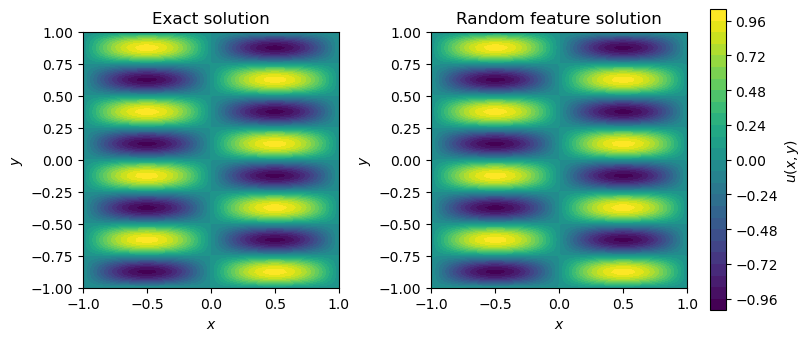

In [37]:
import matplotlib.gridspec as gridspec 


# Predicted solution
U_pred = u_pred.reshape(N, N)
U_true = u_test.reshape(N, N) 
XX = X_test[:, 0:1].reshape(N, N) 
YY = X_test[:, 1:2].reshape(N, N) 
# Use the same color scale for both plots
vmin = min(U_true.min(), U_pred.min())
vmax = max(U_true.max(), U_pred.max())

# Create figure
fig, axes = plt.subplots(
    1, 2,
    figsize=(8, 3.5),
    constrained_layout=True
)

# -----------------------------
# Exact solution
# -----------------------------
contour0 = axes[0].contourf(
    XX, YY, U_true,
    levels=30,
    vmin=vmin,
    vmax=vmax,
    cmap="viridis"
)

axes[0].set_xlabel(r"$x$")
axes[0].set_ylabel(r"$y$")
axes[0].set_title("Exact solution")
axes[0].set_aspect("equal")

# -----------------------------
# Random feature solution
# -----------------------------
contour1 = axes[1].contourf(
    XX, YY, U_pred,
    levels=30,
    vmin=vmin,
    vmax=vmax,
    cmap="viridis"
)

axes[1].set_xlabel(r"$x$")
axes[1].set_ylabel(r"$y$")
axes[1].set_title("Random feature solution")
axes[1].set_aspect("equal")

# -----------------------------
# Shared colorbar
# -----------------------------
cbar = fig.colorbar(
    contour1,
    ax=axes,
    shrink=0.9,
    pad=0.02
)

cbar.set_label(r"$u(x,y)$")

# -----------------------------
# Save figure
# -----------------------------

fig.savefig(
    "Helmholtz_solution.pdf",
    bbox_inches="tight"
)
 
 
fig.savefig(
    "Helmholtz_solution.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()